# PINNsFormer + Adaptive M-ConFIG-4 v2：Risk-Triggered Round-Robin Override × 3 Seeds

本 notebook **只运行 v2 方法本身**，不重复运行任何 baseline。

当前目标是验证第二版梯度刷新调度机制：

> **保留 Fixed Round-Robin 作为稳定刷新骨架，只在某个 task 的历史梯度出现明显 freshness risk 时临时抢占刷新权；抢占后不丢弃原本轮到的 task，而是在下一 step 继续回到原 RR 位置。**

四个训练 task / loss 不变：

$$
L_{u,\mathrm{data}},\qquad
L_{v,\mathrm{data}},\qquad
L_{f_u},\qquad
L_{f_v}.
$$

每个 optimizer step 仍然只允许：

$$
\boxed{1\text{ 个真实 fresh task gradient}}
$$

所以 1000 outer steps 对应约 1000 次真实 task-gradient refresh。

本轮不修改：

- PINNsFormer 网络；
- 4-loss 定义；
- `PseudoMomentumOperator`；
- `ConFIGOperator`；
- 外层 SGD；
- 学习率；
- 数据抽样与三 seed 设置。

**唯一新增变量是：什么时候允许风险任务打断 RR 默认刷新。**


# ⭐⭐⭐ 核心方法：Fixed RR 稳定骨架 + Risk-Triggered Override

## 1. 为什么从 v1 改成 v2

v1 每一步都使用：

$$
S_i=a_i(\epsilon+d_i)
$$

并直接：

$$
i_t=\arg\max_i S_i.
$$

这种方式让全部 1000 个 step 都由 freshness score 控制。它能够识别 task 间不同的梯度老化速度，但也可能过度追逐高波动 task。

v2 改成更保守的机制：

$$
\boxed{
\text{RR 是默认策略，Adaptive 只负责异常干预}
}
$$

## 2. RR Backbone：正常情况下固定轮询

维护一个 `rr_pointer`，依次指向：

```text
u_data -> v_data -> f_u -> f_v -> ...
```

如果没有明显风险，就刷新当前 `rr_pointer` 指向的 task。

与简单的 `step % 4` 不同，本版使用 **stateful RR pointer**：

> 如果某一步被风险 task 抢占，原本轮到的 RR task 不会被永久跳过，`rr_pointer` 保持不动；下一 step 仍优先尝试完成这个原定 task。

因此 override 更接近“中断 / 抢占”，而不是重新洗牌整个调度序列。

## 3. Freshness Risk

### Staleness

$$
a_i(t)=t-t_i^{\mathrm{last\ refresh}}.
$$

### Gradient Drift EMA

当某 task 真正被刷新时，比较刷新前的旧 momentum estimate 与当前 fresh gradient：

$$
r_i(t)
=
\frac{
1-\cos\left(\hat g_i^{\mathrm{old}},g_i^{\mathrm{fresh}}\right)
}{2},
$$

并更新：

$$
d_i\leftarrow \rho d_i+(1-\rho)r_i.
$$

定义风险：

$$
\boxed{
R_i(t)=a_i(t)(\epsilon+d_i(t))
}
$$

## 4. Override 不是“谁最大就一定刷新”

设当前 RR 默认 task 为 $j$，风险最高 task 为：

$$
k=\arg\max_i R_i.
$$

只有同时满足以下条件，才允许 $k$ 抢占 $j$：

$$
R_k>\tau_{\mathrm{abs}}
$$

$$
R_k>\tau_{\mathrm{rel}}\max(R_j,R_{\mathrm{floor}})
$$

$$
a_k\ge A_{\min}
$$

并且 cooldown 已满足。

否则继续正常 RR：

$$
\boxed{i_t=j}
$$

## 5. Max-Age Guard

为了防止连续抢占导致某个 task 长期得不到 fresh gradient：

$$
a_i\ge A_{\max}
\Rightarrow
\text{强制刷新最老 task}.
$$

如果这个最老 task 不是当前 RR 默认 task，也视为一次 safety preemption。

## 6. 最重要的稳定性设计

假设当前 RR 本来轮到 `u_data`，但 `f_v` 风险异常：

```text
RR pointer -> u_data
risk trigger -> f_v 抢占
本 step      -> refresh f_v

下一 step:
RR pointer 仍然 -> u_data
```

也就是 override 是临时中断，原定 RR task 不被跳过。

## 7. 本轮重点指标

- `override_rate`
- `risk_override_count`
- `max_age_preemption_count`
- override 的 task 分布
- refresh allocation
- update-vs-fresh alignment
- physics threshold
- $u/v/p$ 场误差
- wall time
- 排除 diagnostics 后的 core peak VRAM


# ⭐ 核心调度伪代码

```text
输入:
    rr_pointer
    last_refresh_step[4]
    drift_ema[4]
    last_preemption_step
    每 step fresh-gradient budget = 1

前 4 step:
    u_data -> v_data -> f_u -> f_v
    初始化 PseudoMomentum
    rr_pointer = u_data

之后每一步:

    default = rr_pointer

    age_i  = step - last_refresh_i
    risk_i = age_i * (EPS + drift_ema_i)

    1. Max-Age Guard
       如果存在 age_i >= MAX_AGE:
           selected = 最老的 task
           如果 selected != default:
               safety preemption
               rr_pointer 不前进
           否则:
               rr_pointer 正常前进

    2. 否则检查 Risk Override
       candidate = argmax(risk_i)

       只有当:
           candidate != default
           age_candidate >= MIN_OVERRIDE_AGE
           risk_candidate >= ABS_THRESHOLD
           risk_candidate >= REL_RATIO * max(risk_default, RISK_FLOOR)
           cooldown 已满足
       才:
           selected = candidate
           rr_pointer 不前进

    3. 若未触发:
           selected = default
           rr_pointer 前进一格

    4. 只计算 selected 的真实 loss + fresh gradient
    5. 用刷新前 old estimate 与 fresh gradient 更新 drift EMA
    6. 写入 PseudoMomentumOperator
    7. ConFIG 构造公共更新方向
    8. SGD optimizer.step()
```

$$
\boxed{
\text{绝大多数 step 走 RR，少数明显异常 step 才被 adaptive override}
}
$$

scheduler 在选择前 **绝不计算其余 task 的 fresh gradients**。


In [1]:

from pathlib import Path
import os
import sys
import time
import json
import csv
import gc
import random
import math

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

print("Python executable:", sys.executable)
print("Python version   :", sys.version.split()[0])
print("PyTorch          :", torch.__version__)
print("CUDA runtime     :", torch.version.cuda)
print("CUDA available   :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU              :", torch.cuda.get_device_name(0))


Python executable: /home/simplexity/anaconda3/envs/config_pinn/bin/python
Python version   : 3.10.21
PyTorch          : 2.5.1+cu121
CUDA runtime     : 12.1
CUDA available   : True
GPU              : NVIDIA GeForce GTX 1080 Ti


# 实验配置


In [2]:
PINNSFORMER_ROOT = Path(
    os.environ.get("PINNSFORMER_ROOT", "/home/simplexity/cyt/pinnsformer-main")
)

EXPERIMENT_ROOT = Path(
    os.environ.get(
        "PINNSFORMER_CONFIG_ROOT",
        str(PINNSFORMER_ROOT / "pinnsformer-config"),
    )
)

CONFIG_ROOT = Path(
    os.environ.get("CONFIG_ROOT", "/home/simplexity/cyt/ConFIG-main")
)

DATA_PATH = (
    PINNSFORMER_ROOT
    / "demo"
    / "navier_stokes"
    / "cylinder_nektar_wake.mat"
)

OUTPUT_ROOT = (
    EXPERIMENT_ROOT
    / "outputs"
    / "navier_stokes_adaptive_mconfig4_rr_override_v2"
)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

RUN_SEEDS = [0, 1, 2]
FORCE_RERUN = False

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

N_TRAIN = 800
NUM_STEP = 5
TIME_STEP = 1e-2
EPOCHS = 1000
SNAPSHOT = 100

SGD_LR = 1e-4
BETA_1 = 0.9
BETA_2 = 0.999

LOSS_KEYS = ["u_data", "v_data", "f_u", "f_v"]
LOSS_INDEX = {name: i for i, name in enumerate(LOSS_KEYS)}

METHOD_KEY = "adaptive_mconfig4_rr_override_v2"
METHODS = [METHOD_KEY]

# ===== Adaptive Scheduler v2 =====
DRIFT_EMA_RHO = 0.80
DRIFT_INIT = 0.25
SCORE_EPS = 0.05

RISK_ABS_THRESHOLD = 1.00
RISK_REL_RATIO = 2.00
RISK_FLOOR = 0.10
MIN_OVERRIDE_AGE = 2
OVERRIDE_COOLDOWN = 4
MAX_AGE = 8

METRIC_INTERVAL = 10
PROBE_INTERVAL = 37

PHYSICS_THRESHOLDS = [1e-2, 5e-3, 2e-3, 1e-3, 5e-4]

print("PINNSFORMER_ROOT :", PINNSFORMER_ROOT)
print("EXPERIMENT_ROOT  :", EXPERIMENT_ROOT)
print("CONFIG_ROOT      :", CONFIG_ROOT)
print("DATA_PATH        :", DATA_PATH)
print("OUTPUT_ROOT      :", OUTPUT_ROOT)
print("DEVICE           :", DEVICE)
print("RUN_SEEDS        :", RUN_SEEDS)
print()
print("Adaptive M-ConFIG v2:")
print("  DRIFT_EMA_RHO        =", DRIFT_EMA_RHO)
print("  DRIFT_INIT           =", DRIFT_INIT)
print("  SCORE_EPS            =", SCORE_EPS)
print("  RISK_ABS_THRESHOLD   =", RISK_ABS_THRESHOLD)
print("  RISK_REL_RATIO       =", RISK_REL_RATIO)
print("  RISK_FLOOR           =", RISK_FLOOR)
print("  MIN_OVERRIDE_AGE     =", MIN_OVERRIDE_AGE)
print("  OVERRIDE_COOLDOWN    =", OVERRIDE_COOLDOWN)
print("  MAX_AGE              =", MAX_AGE)
print("  PROBE_INTERVAL       =", PROBE_INTERVAL)


PINNSFORMER_ROOT : /home/simplexity/cyt/pinnsformer-main
EXPERIMENT_ROOT  : /home/simplexity/cyt/pinnsformer-main/pinnsformer-config
CONFIG_ROOT      : /home/simplexity/cyt/ConFIG-main
DATA_PATH        : /home/simplexity/cyt/pinnsformer-main/demo/navier_stokes/cylinder_nektar_wake.mat
OUTPUT_ROOT      : /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_adaptive_mconfig4_rr_override_v2
DEVICE           : cuda:0
RUN_SEEDS        : [0, 1, 2]

Adaptive M-ConFIG v2:
  DRIFT_EMA_RHO        = 0.8
  DRIFT_INIT           = 0.25
  SCORE_EPS            = 0.05
  RISK_ABS_THRESHOLD   = 1.0
  RISK_REL_RATIO       = 2.0
  RISK_FLOOR           = 0.1
  MIN_OVERRIDE_AGE     = 2
  OVERRIDE_COOLDOWN    = 4
  MAX_AGE              = 8
  PROBE_INTERVAL       = 37


## v2 参数边界

这组阈值是第二版机制的工程起点，不是理论最优值。

- `RISK_ABS_THRESHOLD=1.0`
- `RISK_REL_RATIO=2.0`
- `MIN_OVERRIDE_AGE=2`
- `OVERRIDE_COOLDOWN=4`
- `MAX_AGE=8`

第一轮先观察 override rate、触发来源和训练稳定性；不要为了单 seed 结果立即大规模调参。


# 导入当前 PINNsFormer / ConFIG 实现

In [3]:

assert DATA_PATH.exists(), f"Missing dataset: {DATA_PATH}"
assert (EXPERIMENT_ROOT / "navier_stokes_common.py").exists()
assert (EXPERIMENT_ROOT / "gradient_diagnostics.py").exists()
assert CONFIG_ROOT.exists(), f"Missing ConFIG repo: {CONFIG_ROOT}"

sys.path.insert(0, str(EXPERIMENT_ROOT))
sys.path.insert(0, str(CONFIG_ROOT))

from navier_stokes_common import (
    PINNsformer,
    init_weights,
    get_n_params,
    load_training_data,
    compute_ns_losses,
    evaluation_tensors,
)
from gradient_diagnostics import gradient_vector, cosine_similarity

from conflictfree.grad_operator import ConFIGOperator
from conflictfree.momentum_operator import PseudoMomentumOperator
from conflictfree.utils import apply_gradient_vector_para_based

import conflictfree
print("conflictfree:", conflictfree.__file__)


conflictfree: /home/simplexity/cyt/ConFIG-main/conflictfree/__init__.py


# 通用工具

In [4]:

def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


def sync_cuda():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def write_rows(path, rows, fieldnames=None):
    rows = list(rows)
    if not rows:
        return
    if fieldnames is None:
        fieldnames = list(rows[0].keys())
    with Path(path).open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def read_rows(path):
    with Path(path).open("r", newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


def safe_mean(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    return float(arr.mean()) if len(arr) else float("nan")


def safe_std(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if len(arr) <= 1:
        return float("nan")
    return float(arr.std(ddof=1))


def relative_l2(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return float(
        np.linalg.norm(y_true - y_pred)
        / (np.linalg.norm(y_true) + 1e-12)
    )


def mae(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return float(np.mean(np.abs(y_true - y_pred)))


def max_abs_error(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return float(np.max(np.abs(y_true - y_pred)))


def align_pressure_mean(p_true, p_pred):
    p_true = np.asarray(p_true).reshape(-1)
    p_pred = np.asarray(p_pred).reshape(-1)
    return p_pred - np.mean(p_pred) + np.mean(p_true)


def model_name(method):
    return {
        "adaptive_mconfig4_rr_override_v2":
            "Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD",
    }[method]

def make_model(device):
    model = PINNsformer(
        d_out=2,
        d_hidden=512,
        d_model=32,
        N=1,
        heads=2,
    ).to(device)
    model.apply(init_weights)
    return model



# 四个 task 的真实单项 loss

为了保持 M-ConFIG 的真实低计算语义，Fixed RR 和 Adaptive 都不能每一步先把完整四项 PDE loss 全部构造出来。

下面实现：

- `u_data`：只构造 $u$ 数据监督；
- `v_data`：只构造 $v$ 数据监督；
- `f_u`：只构造第一条 NS momentum residual；
- `f_v`：只构造第二条 NS momentum residual。

正式运行前会和统一 `compute_ns_losses()` 做 smoke test。


In [5]:

def _psi_pressure(model, x, y, t):
    out = model(x, y, t)
    return out[:, :, 0:1], out[:, :, 1:2]


def compute_single_task_loss(model, batch, task_name):
    x = batch["x"]
    y = batch["y"]
    t = batch["t"]
    u_obs = batch["u"]
    v_obs = batch["v"]

    psi, pressure = _psi_pressure(model, x, y, t)

    if task_name == "u_data":
        u_pred = torch.autograd.grad(
            psi, y,
            grad_outputs=torch.ones_like(psi),
            retain_graph=True,
            create_graph=True,
        )[0]
        return torch.mean((u_pred[:, 0] - u_obs) ** 2)

    if task_name == "v_data":
        v_pred = -torch.autograd.grad(
            psi, x,
            grad_outputs=torch.ones_like(psi),
            retain_graph=True,
            create_graph=True,
        )[0]
        return torch.mean((v_pred[:, 0] - v_obs) ** 2)

    u_pred = torch.autograd.grad(
        psi, y,
        grad_outputs=torch.ones_like(psi),
        retain_graph=True,
        create_graph=True,
    )[0]
    v_pred = -torch.autograd.grad(
        psi, x,
        grad_outputs=torch.ones_like(psi),
        retain_graph=True,
        create_graph=True,
    )[0]

    if task_name == "f_u":
        u_t = torch.autograd.grad(
            u_pred, t,
            grad_outputs=torch.ones_like(u_pred),
            retain_graph=True,
            create_graph=True,
        )[0]
        u_x = torch.autograd.grad(
            u_pred, x,
            grad_outputs=torch.ones_like(u_pred),
            retain_graph=True,
            create_graph=True,
        )[0]
        u_y = torch.autograd.grad(
            u_pred, y,
            grad_outputs=torch.ones_like(u_pred),
            retain_graph=True,
            create_graph=True,
        )[0]
        u_xx = torch.autograd.grad(
            u_x, x,
            grad_outputs=torch.ones_like(u_x),
            retain_graph=True,
            create_graph=True,
        )[0]
        u_yy = torch.autograd.grad(
            u_y, y,
            grad_outputs=torch.ones_like(u_y),
            retain_graph=True,
            create_graph=True,
        )[0]
        p_x = torch.autograd.grad(
            pressure, x,
            grad_outputs=torch.ones_like(pressure),
            retain_graph=True,
            create_graph=True,
        )[0]

        f_u = (
            u_t
            + (u_pred * u_x + v_pred * u_y)
            + p_x
            - 0.01 * (u_xx + u_yy)
        )
        return torch.mean(f_u ** 2)

    if task_name == "f_v":
        v_t = torch.autograd.grad(
            v_pred, t,
            grad_outputs=torch.ones_like(v_pred),
            retain_graph=True,
            create_graph=True,
        )[0]
        v_x = torch.autograd.grad(
            v_pred, x,
            grad_outputs=torch.ones_like(v_pred),
            retain_graph=True,
            create_graph=True,
        )[0]
        v_y = torch.autograd.grad(
            v_pred, y,
            grad_outputs=torch.ones_like(v_pred),
            retain_graph=True,
            create_graph=True,
        )[0]
        v_xx = torch.autograd.grad(
            v_x, x,
            grad_outputs=torch.ones_like(v_x),
            retain_graph=True,
            create_graph=True,
        )[0]
        v_yy = torch.autograd.grad(
            v_y, y,
            grad_outputs=torch.ones_like(v_y),
            retain_graph=True,
            create_graph=True,
        )[0]
        p_y = torch.autograd.grad(
            pressure, y,
            grad_outputs=torch.ones_like(pressure),
            retain_graph=True,
            create_graph=True,
        )[0]

        f_v = (
            v_t
            + (u_pred * v_x + v_pred * v_y)
            + p_y
            - 0.01 * (v_xx + v_yy)
        )
        return torch.mean(f_v ** 2)

    raise ValueError(f"Unknown task: {task_name}")


# Smoke Test：单 task loss / gradient 与公共实现保持一致

In [6]:

RUN_IMPLEMENTATION_SMOKE_TEST = True
SMOKE_N = 32

if RUN_IMPLEMENTATION_SMOKE_TEST:
    device = torch.device(DEVICE)

    set_seed(123)
    smoke_batch, _ = load_training_data(
        DATA_PATH,
        device,
        seed=123,
        n_train=SMOKE_N,
        num_step=NUM_STEP,
        time_step=TIME_STEP,
    )

    set_seed(123)
    smoke_model = make_model(device)

    full_losses = compute_ns_losses(
        smoke_model,
        smoke_batch["x"],
        smoke_batch["y"],
        smoke_batch["t"],
        smoke_batch["u"],
        smoke_batch["v"],
    )

    full_values = {
        key: float(full_losses[key].detach())
        for key in LOSS_KEYS
    }

    full_grads = {}
    for i, key in enumerate(LOSS_KEYS):
        full_grads[key] = gradient_vector(
            full_losses[key],
            smoke_model,
            retain_graph=(i < len(LOSS_KEYS) - 1),
        )

    del full_losses
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    rows = []
    for key in LOSS_KEYS:
        loss_i = compute_single_task_loss(
            smoke_model,
            smoke_batch,
            key,
        )
        grad_i = gradient_vector(
            loss_i,
            smoke_model,
            retain_graph=False,
        )

        ref_loss = full_values[key]
        cur_loss = float(loss_i.detach())

        rel_loss_diff = (
            abs(cur_loss - ref_loss)
            / max(abs(ref_loss), 1e-12)
        )
        grad_cos = cosine_similarity(
            grad_i,
            full_grads[key],
        )
        grad_rel_err = float(
            (grad_i - full_grads[key]).norm()
            / (full_grads[key].norm() + 1e-12)
        )

        rows.append({
            "task": key,
            "relative_loss_diff": rel_loss_diff,
            "gradient_cosine": grad_cos,
            "gradient_relative_error": grad_rel_err,
        })

        del loss_i, grad_i

    for row in rows:
        print(row)

    assert max(r["relative_loss_diff"] for r in rows) < 1e-5
    assert min(r["gradient_cosine"] for r in rows) > 0.9999

    del smoke_model, smoke_batch, full_grads
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("Smoke test passed.")
else:
    print("Smoke test skipped.")


{'task': 'u_data', 'relative_loss_diff': 0.0, 'gradient_cosine': 1.0000001192092896, 'gradient_relative_error': 0.0}
{'task': 'v_data', 'relative_loss_diff': 0.0, 'gradient_cosine': 0.9999998807907104, 'gradient_relative_error': 0.0}
{'task': 'f_u', 'relative_loss_diff': 0.0, 'gradient_cosine': 1.0000001192092896, 'gradient_relative_error': 9.120757482605768e-08}
{'task': 'f_v', 'relative_loss_diff': 0.0, 'gradient_cosine': 1.0, 'gradient_relative_error': 1.1199768579217562e-07}
Smoke test passed.


# PseudoMomentum 状态工具

In [7]:

def make_momentum_operator():
    return PseudoMomentumOperator(
        num_vectors=len(LOSS_KEYS),
        beta_1=BETA_1,
        beta_2=BETA_2,
        gradient_operator=ConFIGOperator(),
    )


def get_bias_corrected_m_hats(operator):
    if operator.m is None:
        return None

    estimates = []
    for i in range(operator.num_vectors):
        count = operator.t_grads[i]
        if count <= 0:
            estimates.append(None)
        else:
            estimates.append(
                operator.m[i]
                / (1 - operator.beta_1 ** count)
            )
    return estimates


def cosine_or_nan(a, b):
    if a is None or b is None:
        return float("nan")
    return cosine_similarity(a, b)


def current_ages_before_refresh(step, last_refresh_step):
    ages = []
    for last in last_refresh_step:
        if last < 0:
            ages.append(float("inf"))
        else:
            ages.append(float(step - last))
    return ages


# ⭐⭐⭐ 核心调度算法代码：`choose_refresh_task_v2`

核心分为三层：

```text
RR backbone
    ↓
risk-trigger override
    ↓
max-age safety guard
```

`rr_pointer` 只在原定 RR task 真正被刷新后前进。若发生抢占，pointer 保持，因此下一 step 会继续尝试原定 task。


In [8]:
# ================================================================
# ⭐⭐⭐ CORE SCHEDULER v2
# Fixed RR backbone + Risk-Triggered Override
# ================================================================

def choose_refresh_task_v2(
    *,
    step,
    last_refresh_step,
    drift_ema,
    rr_pointer,
    last_preemption_step,
):
    if step < len(LOSS_KEYS):
        idx = step
        ages = current_ages_before_refresh(
            step,
            last_refresh_step,
        )
        return idx, {
            "reason": "warmup_init",
            "default_index": idx,
            "candidate_index": idx,
            "ages": ages,
            "risks": [np.nan] * len(LOSS_KEYS),
            "default_risk": np.nan,
            "candidate_risk": np.nan,
            "risk_ratio": np.nan,
            "override_event": False,
            "advance_rr_after_refresh": False,
            "cooldown_ready": False,
        }

    default_idx = int(rr_pointer)

    ages = np.asarray(
        current_ages_before_refresh(
            step,
            last_refresh_step,
        ),
        dtype=float,
    )
    drift = np.asarray(
        drift_ema,
        dtype=float,
    )

    # ⭐ 核心风险公式
    risks = ages * (SCORE_EPS + drift)

    candidate_idx = int(np.argmax(risks))

    default_risk = float(risks[default_idx])
    candidate_risk = float(risks[candidate_idx])
    risk_ratio = (
        candidate_risk
        / max(default_risk, RISK_FLOOR)
    )

    cooldown_ready = (
        last_preemption_step < 0
        or
        (step - last_preemption_step) >= OVERRIDE_COOLDOWN
    )

    # ------------------------------------------------------------
    # Safety layer: Max-Age Guard
    # ------------------------------------------------------------
    overdue = [
        i
        for i, age in enumerate(ages)
        if age >= MAX_AGE
    ]

    if overdue:
        selected_idx = max(
            overdue,
            key=lambda i: (
                ages[i],
                risks[i],
                -i,
            ),
        )

        is_preemption = (
            selected_idx != default_idx
        )

        return selected_idx, {
            "reason": (
                "max_age_guard_preempt"
                if is_preemption
                else "max_age_guard_default"
            ),
            "default_index": default_idx,
            "candidate_index": candidate_idx,
            "ages": ages.tolist(),
            "risks": risks.tolist(),
            "default_risk": default_risk,
            "candidate_risk": candidate_risk,
            "risk_ratio": risk_ratio,
            "override_event": bool(is_preemption),
            "advance_rr_after_refresh":
                bool(selected_idx == default_idx),
            "cooldown_ready": bool(cooldown_ready),
        }

    # ------------------------------------------------------------
    # Adaptive layer: Risk-Triggered Override
    # ------------------------------------------------------------
    should_override = (
        candidate_idx != default_idx
        and ages[candidate_idx] >= MIN_OVERRIDE_AGE
        and candidate_risk >= RISK_ABS_THRESHOLD
        and candidate_risk
            >= RISK_REL_RATIO
            * max(default_risk, RISK_FLOOR)
        and cooldown_ready
    )

    if should_override:
        selected_idx = candidate_idx
        reason = "risk_override"
        override_event = True
        advance_rr = False
    else:
        selected_idx = default_idx
        reason = "rr_backbone"
        override_event = False
        advance_rr = True

    return selected_idx, {
        "reason": reason,
        "default_index": default_idx,
        "candidate_index": candidate_idx,
        "ages": ages.tolist(),
        "risks": risks.tolist(),
        "default_risk": default_risk,
        "candidate_risk": candidate_risk,
        "risk_ratio": risk_ratio,
        "override_event": override_event,
        "advance_rr_after_refresh": advance_rr,
        "cooldown_ready": bool(cooldown_ready),
    }


# ⭐ Gradient Drift 更新

必须先比较：

$$
\hat g_i^{old}\quad\text{vs}\quad g_i^{fresh}
$$

再把当前 fresh gradient 写入 PseudoMomentum。否则会出现信息泄漏。


In [9]:

def observe_and_update_drift(
    *,
    selected_index,
    fresh_gradient,
    operator,
    drift_ema,
):
    m_hats_before = get_bias_corrected_m_hats(operator)

    if (
        m_hats_before is None
        or m_hats_before[selected_index] is None
    ):
        return {
            "old_estimate_fresh_cosine": np.nan,
            "drift_observation": np.nan,
            "relative_estimate_error": np.nan,
            "old_estimate": None,
        }

    old_estimate = m_hats_before[selected_index]

    cos_value = cosine_similarity(
        old_estimate,
        fresh_gradient,
    )

    # cosine in [-1,1] -> drift observation in [0,1]
    drift_obs = float(
        np.clip((1.0 - cos_value) / 2.0, 0.0, 1.0)
    )

    rel_error = float(
        (old_estimate - fresh_gradient).norm()
        / (fresh_gradient.norm() + 1e-12)
    )

    drift_ema[selected_index] = (
        DRIFT_EMA_RHO * drift_ema[selected_index]
        + (1.0 - DRIFT_EMA_RHO) * drift_obs
    )

    return {
        "old_estimate_fresh_cosine": cos_value,
        "drift_observation": drift_obs,
        "relative_estimate_error": rel_error,
        "old_estimate": old_estimate,
    }


# 完整 loss / fresh-gradient probe

In [10]:

def full_loss_values_and_optional_grads(
    model,
    batch,
    *,
    need_grads=False,
):
    losses = compute_ns_losses(
        model,
        batch["x"],
        batch["y"],
        batch["t"],
        batch["u"],
        batch["v"],
    )

    values = {
        key: float(losses[key].detach())
        for key in [
            "total",
            "data",
            "physics",
            "u_data",
            "v_data",
            "f_u",
            "f_v",
        ]
    }

    fresh_grads = None

    if need_grads:
        fresh_grads = {}
        for i, key in enumerate(LOSS_KEYS):
            fresh_grads[key] = gradient_vector(
                losses[key],
                model,
                retain_graph=(i < len(LOSS_KEYS) - 1),
            )

    del losses
    return values, fresh_grads


## Probe 与 VRAM 统计

继续使用：

```text
PROBE_INTERVAL = 37
```

Probe 的额外 fresh gradients 只用于诊断，不参与训练调度。

本版同时修正 v1 的 VRAM 统计问题：

> `max_core_peak_vram_mib` 只在 diagnostics 之前累计；probe/full-loss diagnostics 的峰值只进入 `max_observed_peak_vram_mib_with_diagnostics`。


# Evaluation：保持与前面实验一致

In [11]:

def evaluation_truth(reference, device):
    ev, truth_raw = evaluation_tensors(
        reference,
        device,
        snap=SNAPSHOT,
        num_step=NUM_STEP,
        time_step=TIME_STEP,
    )

    truth = {
        name: np.asarray(value).reshape(-1)
        for name, value in truth_raw.items()
    }
    return ev, truth


def predict_fields(model, ev):
    psi_p = model(
        ev["x"],
        ev["y"],
        ev["t"],
    )

    psi = psi_p[:, :, 0:1]
    p_pred = psi_p[:, :, 1:2]

    u_pred = torch.autograd.grad(
        psi,
        ev["y"],
        grad_outputs=torch.ones_like(psi),
        retain_graph=True,
        create_graph=False,
    )[0]

    v_pred = -torch.autograd.grad(
        psi,
        ev["x"],
        grad_outputs=torch.ones_like(psi),
        retain_graph=False,
        create_graph=False,
    )[0]

    return {
        "u": u_pred.detach().cpu().numpy()[:, 0].reshape(-1),
        "v": v_pred.detach().cpu().numpy()[:, 0].reshape(-1),
        "p": p_pred.detach().cpu().numpy()[:, 0].reshape(-1),
    }


def field_metric_rows(seed, method, truth, pred):
    rows = []

    for field in ["u", "v", "p"]:
        row = {
            "seed": int(seed),
            "method": model_name(method),
            "field": field,
            "relative_l2": relative_l2(
                truth[field],
                pred[field],
            ),
            "mae": mae(
                truth[field],
                pred[field],
            ),
            "max_absolute_error": max_abs_error(
                truth[field],
                pred[field],
            ),
            "mean_aligned_relative_l2": "",
        }

        if field == "p":
            p_aligned = align_pressure_mean(
                truth["p"],
                pred["p"],
            )
            row["mean_aligned_relative_l2"] = relative_l2(
                truth["p"],
                p_aligned,
            )

        rows.append(row)

    return rows


# Probe：update 相对当前 fresh gradients 是否仍安全

In [12]:

def pairwise_fresh_cosines(fresh_grads):
    out = {}
    for i in range(len(LOSS_KEYS)):
        for j in range(i + 1, len(LOSS_KEYS)):
            a = LOSS_KEYS[i]
            b = LOSS_KEYS[j]
            out[f"fresh_cos_{a}__{b}"] = cosine_similarity(
                fresh_grads[a],
                fresh_grads[b],
            )
    return out


def build_probe_row(
    *,
    seed,
    method,
    step,
    selected_index,
    operator,
    last_refresh_step,
    drift_ema,
    g_update,
    fresh_grads,
    full_values,
    algorithm_elapsed_s,
):
    # 注意：这里是 selected task 已完成本 step refresh 之后的 operator 状态。
    m_hats = get_bias_corrected_m_hats(operator)

    post_ages = []
    for last in last_refresh_step:
        post_ages.append(
            np.nan if last < 0 else float(step - last)
        )

    row = {
        "seed": int(seed),
        "method": model_name(method),
        "step": int(step),
        "selected_index": int(selected_index),
        "selected_task": LOSS_KEYS[selected_index],
        "algorithm_elapsed_s": float(algorithm_elapsed_s),
        **full_values,
    }

    for i, key in enumerate(LOSS_KEYS):
        estimate = (
            None
            if m_hats is None
            else m_hats[i]
        )
        fresh = fresh_grads[key]

        row[f"post_age_{key}"] = post_ages[i]
        row[f"drift_ema_{key}"] = float(drift_ema[i])
        row[f"cos_estimate_fresh_{key}"] = cosine_or_nan(
            estimate,
            fresh,
        )
        row[f"cos_update_fresh_{key}"] = cosine_or_nan(
            g_update,
            fresh,
        )

    update_cos = np.asarray(
        [
            row[f"cos_update_fresh_{key}"]
            for key in LOSS_KEYS
        ],
        dtype=float,
    )
    valid = update_cos[np.isfinite(update_cos)]

    row["min_update_fresh_alignment"] = (
        float(valid.min()) if len(valid) else np.nan
    )
    row["mean_update_fresh_alignment"] = (
        float(valid.mean()) if len(valid) else np.nan
    )
    row["nonpositive_update_fresh_rate"] = (
        float(np.mean(valid <= 0))
        if len(valid)
        else np.nan
    )

    row.update(pairwise_fresh_cosines(fresh_grads))
    return row


# ⭐⭐⭐ 训练核心：RR Pointer + Override + M-ConFIG

```text
rr_pointer + risk state
        ↓
choose_refresh_task_v2()
        ↓
只刷新 1 个 selected task
        ↓
更新 drift EMA
        ↓
PseudoMomentum + ConFIG
        ↓
若 selected == RR default:
    rr_pointer 前进
否则:
    rr_pointer 保持
        ↓
SGD update
```


In [13]:
def train_v2(
    seed,
    batch,
    output_dir,
    device,
):
    method = METHOD_KEY
    output_dir = ensure_dir(output_dir)

    set_seed(seed)
    model = make_model(device)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=SGD_LR,
    )
    operator = make_momentum_operator()

    last_refresh_step = [-1] * len(LOSS_KEYS)
    drift_ema = [DRIFT_INIT] * len(LOSS_KEYS)

    rr_pointer = 0
    last_preemption_step = -1

    scheduler_history = []
    metric_history = []
    probe_history = []
    override_events = []

    refresh_counts = {key: 0 for key in LOSS_KEYS}

    selection_reason_counts = {
        "warmup_init": 0,
        "rr_backbone": 0,
        "risk_override": 0,
        "max_age_guard_preempt": 0,
        "max_age_guard_default": 0,
    }

    true_task_gradient_refreshes = 0
    probe_task_gradient_evaluations = 0
    effective_nonzero_parameter_updates = 0

    risk_override_count = 0
    max_age_preemption_count = 0
    total_preemption_count = 0

    diagnostic_time_s = 0.0
    scheduler_decision_time_s = 0.0
    drift_bookkeeping_time_s = 0.0

    max_core_peak_mib = 0.0
    max_observed_peak_mib = 0.0

    print()
    print("=" * 100)
    print(f"seed={seed} | {model_name(method)}")
    print("=" * 100)
    print("params:", get_n_params(model))

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    sync_cuda()
    wall_start = time.perf_counter()

    for step in tqdm(
        range(EPOCHS),
        desc=f"v2 seed={seed}",
    ):
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats(device)

        # 1. Scheduler
        scheduler_start = time.perf_counter()

        selected_index, scheduler_info = choose_refresh_task_v2(
            step=step,
            last_refresh_step=last_refresh_step,
            drift_ema=drift_ema,
            rr_pointer=rr_pointer,
            last_preemption_step=last_preemption_step,
        )

        scheduler_decision_time_s += (
            time.perf_counter() - scheduler_start
        )

        selected_task = LOSS_KEYS[selected_index]
        default_index = int(scheduler_info["default_index"])
        default_task = LOSS_KEYS[default_index]
        candidate_index = int(scheduler_info["candidate_index"])
        candidate_task = LOSS_KEYS[candidate_index]

        ages_before = scheduler_info["ages"]
        risks_before = scheduler_info["risks"]
        drift_before = list(drift_ema)

        reason = scheduler_info["reason"]
        selection_reason_counts[reason] += 1

        # 2. Only one true task gradient
        selected_loss = compute_single_task_loss(
            model,
            batch,
            selected_task,
        )

        selected_grad = gradient_vector(
            selected_loss,
            model,
            retain_graph=False,
        )

        true_task_gradient_refreshes += 1
        refresh_counts[selected_task] += 1

        # 3. Drift update before writing current fresh gradient
        drift_start = time.perf_counter()

        drift_info = observe_and_update_drift(
            selected_index=selected_index,
            fresh_gradient=selected_grad,
            operator=operator,
            drift_ema=drift_ema,
        )

        drift_bookkeeping_time_s += (
            time.perf_counter() - drift_start
        )

        # 4. PseudoMomentum + ConFIG
        g_update = operator.calculate_gradient(
            selected_index,
            selected_grad,
        )

        last_refresh_step[selected_index] = step

        # 5. RR pointer / preemption state
        is_preemption = bool(
            scheduler_info["override_event"]
        )

        if is_preemption:
            total_preemption_count += 1
            last_preemption_step = step

            if reason == "risk_override":
                risk_override_count += 1
            elif reason == "max_age_guard_preempt":
                max_age_preemption_count += 1

        if scheduler_info["advance_rr_after_refresh"]:
            rr_pointer = (
                rr_pointer + 1
            ) % len(LOSS_KEYS)

        scheduler_row = {
            "seed": int(seed),
            "method": model_name(method),
            "step": int(step),
            "selected_index": int(selected_index),
            "selected_task": selected_task,
            "default_index": int(default_index),
            "default_task": default_task,
            "candidate_index": int(candidate_index),
            "candidate_task": candidate_task,
            "selection_reason": reason,
            "override_event": int(is_preemption),
            "rr_pointer_after_step": int(rr_pointer),
            "selected_loss_value":
                float(selected_loss.detach()),
            "default_risk":
                scheduler_info["default_risk"],
            "candidate_risk":
                scheduler_info["candidate_risk"],
            "risk_ratio":
                scheduler_info["risk_ratio"],
            "cooldown_ready":
                int(scheduler_info["cooldown_ready"]),
            "old_estimate_fresh_cosine":
                drift_info["old_estimate_fresh_cosine"],
            "drift_observation":
                drift_info["drift_observation"],
            "relative_estimate_error":
                drift_info["relative_estimate_error"],
        }

        for i, key in enumerate(LOSS_KEYS):
            scheduler_row[f"age_before_{key}"] = ages_before[i]
            scheduler_row[f"drift_before_{key}"] = drift_before[i]
            scheduler_row[f"risk_before_{key}"] = risks_before[i]
            scheduler_row[f"drift_after_{key}"] = drift_ema[i]

        scheduler_history.append(scheduler_row)

        if is_preemption:
            override_events.append(dict(scheduler_row))

        # 6. Write gradient vector for SGD
        optimizer.zero_grad(set_to_none=True)
        apply_gradient_vector_para_based(
            model,
            g_update,
        )

        update_norm = float(g_update.norm().detach())
        if update_norm > 0:
            effective_nonzero_parameter_updates += 1

        # 7. Core VRAM BEFORE diagnostics
        if torch.cuda.is_available():
            core_peak_this_step = (
                torch.cuda.max_memory_allocated(device)
                / 1024**2
            )
            max_core_peak_mib = max(
                max_core_peak_mib,
                core_peak_this_step,
            )
        else:
            core_peak_this_step = np.nan

        # 8. Diagnostics
        is_metric = (
            step % METRIC_INTERVAL == 0
            or step == EPOCHS - 1
        )
        is_probe = (
            step % PROBE_INTERVAL == 0
            or step == EPOCHS - 1
        )

        if is_metric or is_probe:
            sync_cuda()
            diag_start = time.perf_counter()

            full_values, fresh_grads = (
                full_loss_values_and_optional_grads(
                    model,
                    batch,
                    need_grads=is_probe,
                )
            )

            if is_probe:
                probe_task_gradient_evaluations += len(LOSS_KEYS)

            sync_cuda()
            diag_elapsed = (
                time.perf_counter() - diag_start
            )
            diagnostic_time_s += diag_elapsed

            elapsed_wall = (
                time.perf_counter() - wall_start
            )
            algorithm_elapsed_s = max(
                0.0,
                elapsed_wall - diagnostic_time_s,
            )

            if is_metric:
                metric_history.append({
                    "seed": int(seed),
                    "method": model_name(method),
                    "step": int(step),
                    "selected_task": selected_task,
                    "selection_reason": reason,
                    "algorithm_elapsed_s":
                        float(algorithm_elapsed_s),
                    "lr":
                        float(optimizer.param_groups[0]["lr"]),
                    **full_values,
                })

            if is_probe:
                probe_history.append(
                    build_probe_row(
                        seed=seed,
                        method=method,
                        step=step,
                        selected_index=selected_index,
                        operator=operator,
                        last_refresh_step=last_refresh_step,
                        drift_ema=drift_ema,
                        g_update=g_update,
                        fresh_grads=fresh_grads,
                        full_values=full_values,
                        algorithm_elapsed_s=algorithm_elapsed_s,
                    )
                )

            if torch.cuda.is_available():
                observed_peak = (
                    torch.cuda.max_memory_allocated(device)
                    / 1024**2
                )
                max_observed_peak_mib = max(
                    max_observed_peak_mib,
                    observed_peak,
                )

            if fresh_grads is not None:
                del fresh_grads

        # 9. Parameter update
        optimizer.step()

        if torch.cuda.is_available():
            # This may include diagnostics, so it is observed-only.
            observed_after_step = (
                torch.cuda.max_memory_allocated(device)
                / 1024**2
            )
            max_observed_peak_mib = max(
                max_observed_peak_mib,
                observed_after_step,
            )

        del selected_loss, selected_grad, g_update

    sync_cuda()

    total_wall_time_s = (
        time.perf_counter() - wall_start
    )
    algorithm_wall_est_s = max(
        0.0,
        total_wall_time_s - diagnostic_time_s,
    )

    post_warmup_steps = max(
        EPOCHS - len(LOSS_KEYS),
        1,
    )

    preemption_rate = (
        total_preemption_count
        / post_warmup_steps
    )
    risk_override_rate = (
        risk_override_count
        / post_warmup_steps
    )
    max_age_preemption_rate = (
        max_age_preemption_count
        / post_warmup_steps
    )

    adaptive_overhead_time_s = (
        scheduler_decision_time_s
        + drift_bookkeeping_time_s
    )

    torch.save(
        model.state_dict(),
        output_dir / "model.pt",
    )

    write_rows(
        output_dir / "scheduler_history.csv",
        scheduler_history,
    )
    write_rows(
        output_dir / "probe_history.csv",
        probe_history,
    )
    write_rows(
        output_dir / "metric_history.csv",
        metric_history,
    )

    override_fieldnames = (
        list(scheduler_history[0].keys())
        if scheduler_history
        else ["seed", "method", "step", "selected_task"]
    )

    with (
        output_dir / "override_events.csv"
    ).open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=override_fieldnames,
        )
        writer.writeheader()
        for row in override_events:
            writer.writerow(row)

    refresh_rows = [
        {
            "seed": int(seed),
            "method": model_name(method),
            "task": key,
            "refresh_count": int(refresh_counts[key]),
            "refresh_fraction":
                float(
                    refresh_counts[key]
                    / true_task_gradient_refreshes
                ),
        }
        for key in LOSS_KEYS
    ]
    write_rows(
        output_dir / "refresh_counts.csv",
        refresh_rows,
    )

    reason_rows = [
        {
            "seed": int(seed),
            "method": model_name(method),
            "selection_reason": key,
            "count": int(value),
            "fraction_of_all_steps":
                float(value / EPOCHS),
        }
        for key, value
        in selection_reason_counts.items()
    ]
    write_rows(
        output_dir / "selection_reason_counts.csv",
        reason_rows,
    )

    meta = {
        "seed": int(seed),
        "method": model_name(method),
        "method_key": method,
        "outer_optimizer": "SGD",
        "sgd_lr": SGD_LR,
        "beta_1": BETA_1,
        "beta_2": BETA_2,
        "epochs": EPOCHS,
        "n_train": N_TRAIN,
        "num_step": NUM_STEP,
        "time_step": TIME_STEP,
        "snapshot": SNAPSHOT,
        "metric_interval": METRIC_INTERVAL,
        "probe_interval": PROBE_INTERVAL,
        "drift_ema_rho": DRIFT_EMA_RHO,
        "drift_init": DRIFT_INIT,
        "score_eps": SCORE_EPS,
        "risk_abs_threshold": RISK_ABS_THRESHOLD,
        "risk_rel_ratio": RISK_REL_RATIO,
        "risk_floor": RISK_FLOOR,
        "min_override_age": MIN_OVERRIDE_AGE,
        "override_cooldown": OVERRIDE_COOLDOWN,
        "max_age": MAX_AGE,
        "model_params": int(get_n_params(model)),
        "true_task_gradient_refreshes":
            int(true_task_gradient_refreshes),
        "probe_task_gradient_evaluations":
            int(probe_task_gradient_evaluations),
        "effective_nonzero_parameter_updates":
            int(effective_nonzero_parameter_updates),
        "risk_override_count":
            int(risk_override_count),
        "max_age_preemption_count":
            int(max_age_preemption_count),
        "total_preemption_count":
            int(total_preemption_count),
        "risk_override_rate":
            float(risk_override_rate),
        "max_age_preemption_rate":
            float(max_age_preemption_rate),
        "preemption_rate":
            float(preemption_rate),
        "scheduler_decision_time_s":
            float(scheduler_decision_time_s),
        "drift_bookkeeping_time_s":
            float(drift_bookkeeping_time_s),
        "adaptive_overhead_time_s":
            float(adaptive_overhead_time_s),
        "total_wall_time_s_with_diagnostics":
            float(total_wall_time_s),
        "diagnostic_time_s":
            float(diagnostic_time_s),
        "algorithm_wall_time_est_s":
            float(algorithm_wall_est_s),
        "algorithm_wall_time_est_min":
            float(algorithm_wall_est_s / 60.0),
        "max_core_peak_vram_mib":
            float(max_core_peak_mib),
        "max_observed_peak_vram_mib_with_diagnostics":
            float(max_observed_peak_mib),
        "core_vram_measurement_note":
            (
                "core peak accumulated only before diagnostics; "
                "probe/full-loss diagnostic peaks excluded"
            ),
        "refresh_counts": refresh_counts,
        "selection_reason_counts":
            selection_reason_counts,
    }

    with (
        output_dir / "run_meta.json"
    ).open("w", encoding="utf-8") as f:
        json.dump(
            meta,
            f,
            ensure_ascii=False,
            indent=2,
        )

    print("true fresh refreshes :", true_task_gradient_refreshes)
    print("refresh allocation   :", refresh_counts)
    print("selection reasons    :", selection_reason_counts)
    print("risk overrides       :", risk_override_count)
    print("max-age preemptions  :", max_age_preemption_count)
    print(
        "total preemption rate:",
        f"{100.0 * preemption_rate:.2f}%",
    )
    print(
        "adaptive overhead    :",
        f"{adaptive_overhead_time_s:.4f} s",
    )
    print(
        "algorithm wall est   :",
        f"{algorithm_wall_est_s / 60.0:.3f} min",
    )
    print(
        "diagnostic overhead  :",
        f"{diagnostic_time_s:.2f} s",
    )
    print(
        "max core peak VRAM   :",
        f"{max_core_peak_mib:.2f} MiB",
    )
    print(
        "max observed + probe :",
        f"{max_observed_peak_mib:.2f} MiB",
    )

    return (
        model,
        scheduler_history,
        metric_history,
        probe_history,
        override_events,
        refresh_rows,
        reason_rows,
        meta,
    )


# Physics Threshold / Time-to-Target

In [14]:

def threshold_rows_from_metrics(
    seed,
    method,
    metric_history,
):
    rows = []

    for threshold in PHYSICS_THRESHOLDS:
        hit = None

        for row in metric_history:
            if float(row["physics"]) < threshold:
                hit = row
                break

        rows.append({
            "seed": int(seed),
            "method": model_name(method),
            "threshold": float(threshold),
            "first_sampled_step_below": (
                np.nan
                if hit is None
                else int(hit["step"])
            ),
            "algorithm_time_to_target_s": (
                np.nan
                if hit is None
                else float(hit["algorithm_elapsed_s"])
            ),
        })

    return rows


# 场重建评估与保存

In [15]:

def evaluate_and_save(
    seed,
    method,
    model,
    reference,
    output_dir,
    device,
):
    ev, truth = evaluation_truth(
        reference,
        device,
    )
    pred = predict_fields(
        model,
        ev,
    )

    rows = field_metric_rows(
        seed,
        method,
        truth,
        pred,
    )

    write_rows(
        Path(output_dir) / "field_metrics.csv",
        rows,
    )

    p_aligned = align_pressure_mean(
        truth["p"],
        pred["p"],
    )

    np.savez(
        Path(output_dir) / "predictions.npz",
        truth_u=truth["u"],
        truth_v=truth["v"],
        truth_p=truth["p"],
        pred_u=pred["u"],
        pred_v=pred["v"],
        pred_p=pred["p"],
        pred_p_mean_aligned=p_aligned,
    )

    del ev
    return rows


# 正式实验：只运行 Adaptive M-ConFIG v2 × 3 Seeds

不会重新训练 Fixed RR、Adaptive v1、Full Refresh、ConFIG-2、ConFIG-4 或 Adam。

当前 notebook 只负责产生 v2 自身完整三 seed 结果。


In [16]:
device = torch.device(DEVICE)
method = METHOD_KEY

for seed in RUN_SEEDS:
    set_seed(seed)

    batch, reference = load_training_data(
        DATA_PATH,
        device,
        seed=seed,
        n_train=N_TRAIN,
        num_step=NUM_STEP,
        time_step=TIME_STEP,
    )

    method_dir = ensure_dir(
        OUTPUT_ROOT
        / f"seed_{seed}"
        / method
    )

    required = [
        method_dir / "model.pt",
        method_dir / "scheduler_history.csv",
        method_dir / "metric_history.csv",
        method_dir / "probe_history.csv",
        method_dir / "override_events.csv",
        method_dir / "refresh_counts.csv",
        method_dir / "selection_reason_counts.csv",
        method_dir / "run_meta.json",
        method_dir / "field_metrics.csv",
        method_dir / "threshold_steps.csv",
    ]

    complete = all(p.exists() for p in required)

    if complete and not FORCE_RERUN:
        print(
            f"[reuse] seed={seed} | {model_name(method)}"
        )
        del batch, reference
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        continue

    (
        model,
        scheduler_history,
        metric_history,
        probe_history,
        override_events,
        refresh_rows,
        reason_rows,
        meta,
    ) = train_v2(
        seed,
        batch,
        method_dir,
        device,
    )

    field_rows = evaluate_and_save(
        seed,
        method,
        model,
        reference,
        method_dir,
        device,
    )

    threshold_rows = threshold_rows_from_metrics(
        seed,
        method,
        metric_history,
    )

    write_rows(
        method_dir / "threshold_steps.csv",
        threshold_rows,
    )

    print("field metrics:")
    for row in field_rows:
        print(row)

    print("thresholds:")
    for row in threshold_rows:
        print(row)

    del (
        model,
        scheduler_history,
        metric_history,
        probe_history,
        override_events,
        refresh_rows,
        reason_rows,
        batch,
        reference,
    )

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("Adaptive M-ConFIG v2 runs finished or reused.")



seed=0 | Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD
params: 454106


v2 seed=0: 100%|██████████| 1000/1000 [04:02<00:00,  4.12it/s]


true fresh refreshes : 1000
refresh allocation   : {'u_data': 247, 'v_data': 258, 'f_u': 249, 'f_v': 246}
selection reasons    : {'warmup_init': 4, 'rr_backbone': 983, 'risk_override': 13, 'max_age_guard_preempt': 0, 'max_age_guard_default': 0}
risk overrides       : 13
max-age preemptions  : 0
total preemption rate: 1.31%
adaptive overhead    : 7.7701 s
algorithm wall est   : 3.316 min
diagnostic overhead  : 43.90 s
max core peak VRAM   : 4105.13 MiB
max observed + probe : 8414.47 MiB
field metrics:
{'seed': 0, 'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'field': 'u', 'relative_l2': 0.054660851899923674, 'mae': 0.0367414517586308, 'max_absolute_error': 0.26096148025412963, 'mean_aligned_relative_l2': ''}
{'seed': 0, 'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'field': 'v', 'relative_l2': 0.19689279343074767, 'mae': 0.04054002752037984, 'max_absolute_error': 0.17304256672806517, 'mean_aligned_relative_l2': ''}
{'seed': 0, 'method': 'Adaptive M-ConF

v2 seed=1: 100%|██████████| 1000/1000 [03:52<00:00,  4.31it/s]


true fresh refreshes : 1000
refresh allocation   : {'u_data': 247, 'v_data': 258, 'f_u': 248, 'f_v': 247}
selection reasons    : {'warmup_init': 4, 'rr_backbone': 984, 'risk_override': 12, 'max_age_guard_preempt': 0, 'max_age_guard_default': 0}
risk overrides       : 12
max-age preemptions  : 0
total preemption rate: 1.20%
adaptive overhead    : 7.9190 s
algorithm wall est   : 3.173 min
diagnostic overhead  : 41.77 s
max core peak VRAM   : 4105.13 MiB
max observed + probe : 8414.47 MiB
field metrics:
{'seed': 1, 'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'field': 'u', 'relative_l2': 0.046669975352637595, 'mae': 0.0316647600025864, 'max_absolute_error': 0.25348636397582425, 'mean_aligned_relative_l2': ''}
{'seed': 1, 'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'field': 'v', 'relative_l2': 0.14648174105218859, 'mae': 0.028416940576388067, 'max_absolute_error': 0.14897059263367118, 'mean_aligned_relative_l2': ''}
{'seed': 1, 'method': 'Adaptive M-Con

v2 seed=2: 100%|██████████| 1000/1000 [03:56<00:00,  4.24it/s]


true fresh refreshes : 1000
refresh allocation   : {'u_data': 250, 'v_data': 250, 'f_u': 250, 'f_v': 250}
selection reasons    : {'warmup_init': 4, 'rr_backbone': 996, 'risk_override': 0, 'max_age_guard_preempt': 0, 'max_age_guard_default': 0}
risk overrides       : 0
max-age preemptions  : 0
total preemption rate: 0.00%
adaptive overhead    : 8.0063 s
algorithm wall est   : 3.229 min
diagnostic overhead  : 42.35 s
max core peak VRAM   : 4105.13 MiB
max observed + probe : 8414.47 MiB
field metrics:
{'seed': 2, 'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'field': 'u', 'relative_l2': 0.06837355027021608, 'mae': 0.04368854129241939, 'max_absolute_error': 0.28917929635549533, 'mean_aligned_relative_l2': ''}
{'seed': 2, 'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'field': 'v', 'relative_l2': 0.20466083522369363, 'mae': 0.04148637949610216, 'max_absolute_error': 0.18983873328521877, 'mean_aligned_relative_l2': ''}
{'seed': 2, 'method': 'Adaptive M-ConFIG

# 聚合 v2 三 Seeds


In [17]:
AGG_DIR = ensure_dir(
    OUTPUT_ROOT / "aggregate"
)

all_field_rows = []
all_metric_rows = []
all_probe_rows = []
all_scheduler_rows = []
all_override_rows = []
all_refresh_rows = []
all_reason_rows = []
all_threshold_rows = []
all_meta_rows = []

method = METHOD_KEY

for seed in RUN_SEEDS:
    method_dir = (
        OUTPUT_ROOT
        / f"seed_{seed}"
        / method
    )

    paths = {
        "field": method_dir / "field_metrics.csv",
        "metric": method_dir / "metric_history.csv",
        "probe": method_dir / "probe_history.csv",
        "scheduler": method_dir / "scheduler_history.csv",
        "override": method_dir / "override_events.csv",
        "refresh": method_dir / "refresh_counts.csv",
        "reason": method_dir / "selection_reason_counts.csv",
        "threshold": method_dir / "threshold_steps.csv",
        "meta": method_dir / "run_meta.json",
    }

    if not all(p.exists() for p in paths.values()):
        print("skip incomplete seed:", seed)
        continue

    all_field_rows.extend(read_rows(paths["field"]))
    all_metric_rows.extend(read_rows(paths["metric"]))
    all_probe_rows.extend(read_rows(paths["probe"]))
    all_scheduler_rows.extend(read_rows(paths["scheduler"]))
    all_override_rows.extend(read_rows(paths["override"]))
    all_refresh_rows.extend(read_rows(paths["refresh"]))
    all_reason_rows.extend(read_rows(paths["reason"]))
    all_threshold_rows.extend(read_rows(paths["threshold"]))

    with paths["meta"].open(
        "r",
        encoding="utf-8",
    ) as f:
        all_meta_rows.append(json.load(f))

write_rows(
    AGG_DIR / "all_field_metrics.csv",
    all_field_rows,
)
write_rows(
    AGG_DIR / "all_metric_history.csv",
    all_metric_rows,
)
write_rows(
    AGG_DIR / "all_probe_history.csv",
    all_probe_rows,
)
write_rows(
    AGG_DIR / "all_scheduler_history.csv",
    all_scheduler_rows,
)

override_fieldnames = (
    list(all_scheduler_rows[0].keys())
    if all_scheduler_rows
    else ["seed", "method", "step", "selected_task"]
)
with (
    AGG_DIR / "all_override_events.csv"
).open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=override_fieldnames,
    )
    writer.writeheader()
    for row in all_override_rows:
        writer.writerow(row)

write_rows(
    AGG_DIR / "all_refresh_counts.csv",
    all_refresh_rows,
)
write_rows(
    AGG_DIR / "all_selection_reason_counts.csv",
    all_reason_rows,
)
write_rows(
    AGG_DIR / "all_threshold_steps.csv",
    all_threshold_rows,
)
write_rows(
    AGG_DIR / "all_run_meta.csv",
    all_meta_rows,
)

print("field rows    :", len(all_field_rows))
print("metric rows   :", len(all_metric_rows))
print("probe rows    :", len(all_probe_rows))
print("scheduler rows:", len(all_scheduler_rows))
print("override rows :", len(all_override_rows))
print("refresh rows  :", len(all_refresh_rows))
print("threshold rows:", len(all_threshold_rows))


field rows    : 9
metric rows   : 303
probe rows    : 84
scheduler rows: 3000
override rows : 25
refresh rows  : 12
threshold rows: 15


# v2 主指标：3-seed mean ± std


In [18]:
def field_metric_values(
    method_label,
    field,
    metric,
):
    vals = []

    for row in all_field_rows:
        if (
            row["method"] == method_label
            and row["field"] == field
        ):
            raw = row.get(metric, "")
            if raw != "":
                vals.append(float(raw))

    return vals


def final_metric_per_run(
    method_label,
    metric,
):
    vals = []

    for seed in RUN_SEEDS:
        rows = [
            r
            for r in all_metric_rows
            if (
                r["method"] == method_label
                and int(r["seed"]) == seed
            )
        ]

        if rows:
            rows = sorted(
                rows,
                key=lambda r: int(r["step"]),
            )
            vals.append(float(rows[-1][metric]))

    return vals


def mean_metric_per_run(
    method_label,
    metric,
):
    vals = []

    for seed in RUN_SEEDS:
        rows = [
            r
            for r in all_metric_rows
            if (
                r["method"] == method_label
                and int(r["seed"]) == seed
            )
        ]

        if rows:
            vals.append(
                safe_mean(
                    [float(r[metric]) for r in rows]
                )
            )

    return vals


summary_rows = []

for method in METHODS:
    label = model_name(method)

    specs = [
        (
            "u_relative_l2",
            field_metric_values(
                label, "u", "relative_l2"
            ),
        ),
        (
            "v_relative_l2",
            field_metric_values(
                label, "v", "relative_l2"
            ),
        ),
        (
            "p_raw_relative_l2",
            field_metric_values(
                label, "p", "relative_l2"
            ),
        ),
        (
            "p_mean_aligned_relative_l2",
            field_metric_values(
                label,
                "p",
                "mean_aligned_relative_l2",
            ),
        ),
        (
            "final_physics_loss",
            final_metric_per_run(
                label, "physics"
            ),
        ),
        (
            "mean_sampled_physics_loss",
            mean_metric_per_run(
                label, "physics"
            ),
        ),
    ]

    meta_for_method = [
        r
        for r in all_meta_rows
        if r["method"] == label
    ]

    for meta_metric in [
        "algorithm_wall_time_est_min",
        "max_core_peak_vram_mib",
        "true_task_gradient_refreshes",
        "effective_nonzero_parameter_updates",
        "risk_override_count",
        "max_age_preemption_count",
        "total_preemption_count",
        "preemption_rate",
        "scheduler_decision_time_s",
        "drift_bookkeeping_time_s",
        "adaptive_overhead_time_s",
    ]:
        specs.append((
            meta_metric,
            [
                float(r[meta_metric])
                for r in meta_for_method
            ],
        ))

    for metric, vals in specs:
        summary_rows.append({
            "method": label,
            "metric": metric,
            "n": len(vals),
            "mean": safe_mean(vals),
            "std": safe_std(vals),
        })

write_rows(
    AGG_DIR / "mean_std_summary.csv",
    summary_rows,
)

for row in summary_rows:
    print(row)


{'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'metric': 'u_relative_l2', 'n': 3, 'mean': 0.05656812584092578, 'std': 0.010976773727523708}
{'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'metric': 'v_relative_l2', 'n': 3, 'mean': 0.18267845656887663, 'std': 0.03158697957974571}
{'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'metric': 'p_raw_relative_l2', 'n': 3, 'mean': 8.693476351178921, 'std': 7.423994254113065}
{'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'metric': 'p_mean_aligned_relative_l2', 'n': 3, 'mean': 0.28721071721040453, 'std': 0.06395335573173921}
{'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'metric': 'final_physics_loss', 'n': 3, 'mean': 0.000848809004916499, 'std': 0.00011729790934067254}
{'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'metric': 'mean_sampled_physics_loss', 'n': 3, 'mean': 0.004666217123680799, 'std': 0.0006368989921286146}
{'method': 'Adaptive M-Con

# Physics Threshold：Step + Time-to-Target


In [19]:

threshold_summary_rows = []

for method in METHODS:
    label = model_name(method)

    for threshold in PHYSICS_THRESHOLDS:
        rows = [
            r
            for r in all_threshold_rows
            if (
                r["method"] == label
                and np.isclose(
                    float(r["threshold"]),
                    threshold,
                )
            )
        ]

        steps = [
            float(r["first_sampled_step_below"])
            for r in rows
            if np.isfinite(
                float(r["first_sampled_step_below"])
            )
        ]

        times = [
            float(r["algorithm_time_to_target_s"])
            for r in rows
            if np.isfinite(
                float(r["algorithm_time_to_target_s"])
            )
        ]

        threshold_summary_rows.append({
            "method": label,
            "threshold": threshold,
            "n_crossed": len(steps),
            "mean_step": safe_mean(steps),
            "std_step": safe_std(steps),
            "mean_algorithm_time_s": safe_mean(times),
            "std_algorithm_time_s": safe_std(times),
        })

write_rows(
    AGG_DIR / "threshold_mean_std.csv",
    threshold_summary_rows,
)

for row in threshold_summary_rows:
    print(row)


{'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'threshold': 0.01, 'n_crossed': 3, 'mean_step': 100.0, 'std_step': 10.0, 'mean_algorithm_time_s': 20.816750348681428, 'std_algorithm_time_s': 3.4329674033976514}
{'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'threshold': 0.005, 'n_crossed': 3, 'mean_step': 183.33333333333334, 'std_step': 40.414518843273804, 'mean_algorithm_time_s': 37.14229853069992, 'std_algorithm_time_s': 9.013990322235726}
{'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'threshold': 0.002, 'n_crossed': 3, 'mean_step': 343.3333333333333, 'std_step': 30.550504633038933, 'mean_algorithm_time_s': 67.44380353200056, 'std_algorithm_time_s': 5.804177170023706}
{'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'threshold': 0.001, 'n_crossed': 3, 'mean_step': 593.3333333333334, 'std_step': 32.145502536643185, 'mean_algorithm_time_s': 115.7810399394172, 'std_algorithm_time_s': 4.401997900678007}
{'method': 'Adaptive

# ⭐ Refresh Allocation：v2 实际把 1000 次刷新分给了谁

结合 preemption rate、selection reason、field error、physics convergence 与 alignment 一起判断。

非均匀分配本身不是成功标准。


In [20]:

refresh_summary_rows = []

for method in METHODS:
    label = model_name(method)

    for task in LOSS_KEYS:
        vals_count = [
            float(r["refresh_count"])
            for r in all_refresh_rows
            if (
                r["method"] == label
                and r["task"] == task
            )
        ]

        vals_fraction = [
            float(r["refresh_fraction"])
            for r in all_refresh_rows
            if (
                r["method"] == label
                and r["task"] == task
            )
        ]

        refresh_summary_rows.append({
            "method": label,
            "task": task,
            "n_seed": len(vals_count),
            "mean_refresh_count": safe_mean(vals_count),
            "std_refresh_count": safe_std(vals_count),
            "mean_refresh_fraction": safe_mean(vals_fraction),
            "std_refresh_fraction": safe_std(vals_fraction),
        })

write_rows(
    AGG_DIR / "refresh_allocation_summary.csv",
    refresh_summary_rows,
)

for row in refresh_summary_rows:
    print(row)


{'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'task': 'u_data', 'n_seed': 3, 'mean_refresh_count': 248.0, 'std_refresh_count': 1.7320508075688772, 'mean_refresh_fraction': 0.248, 'std_refresh_fraction': 0.001732050807568879}
{'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'task': 'v_data', 'n_seed': 3, 'mean_refresh_count': 255.33333333333334, 'std_refresh_count': 4.618802153517007, 'mean_refresh_fraction': 0.25533333333333336, 'std_refresh_fraction': 0.004618802153517011}
{'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'task': 'f_u', 'n_seed': 3, 'mean_refresh_count': 249.0, 'std_refresh_count': 1.0, 'mean_refresh_fraction': 0.249, 'std_refresh_fraction': 0.0010000000000000009}
{'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'task': 'f_v', 'n_seed': 3, 'mean_refresh_count': 247.66666666666666, 'std_refresh_count': 2.081665999466133, 'mean_refresh_fraction': 0.24766666666666667, 'std_refresh_fraction': 0.0020816659994661

# Update-vs-Fresh Alignment 汇总


In [21]:

alignment_summary_rows = []

for method in METHODS:
    label = model_name(method)

    per_seed_min_alignment = []
    per_seed_nonpositive = []

    for seed in RUN_SEEDS:
        rows = [
            r
            for r in all_probe_rows
            if (
                r["method"] == label
                and int(r["seed"]) == seed
            )
        ]

        if not rows:
            continue

        min_vals = [
            float(r["min_update_fresh_alignment"])
            for r in rows
            if np.isfinite(
                float(r["min_update_fresh_alignment"])
            )
        ]

        nonpos_vals = [
            float(r["nonpositive_update_fresh_rate"])
            for r in rows
            if np.isfinite(
                float(r["nonpositive_update_fresh_rate"])
            )
        ]

        per_seed_min_alignment.append(
            safe_mean(min_vals)
        )
        per_seed_nonpositive.append(
            safe_mean(nonpos_vals)
        )

    alignment_summary_rows.extend([
        {
            "method": label,
            "metric":
                "mean_probe_min_update_fresh_alignment",
            "n_seed":
                len(per_seed_min_alignment),
            "mean":
                safe_mean(per_seed_min_alignment),
            "std":
                safe_std(per_seed_min_alignment),
        },
        {
            "method": label,
            "metric":
                "mean_probe_nonpositive_update_fresh_rate",
            "n_seed":
                len(per_seed_nonpositive),
            "mean":
                safe_mean(per_seed_nonpositive),
            "std":
                safe_std(per_seed_nonpositive),
        },
    ])

write_rows(
    AGG_DIR / "update_fresh_alignment_summary.csv",
    alignment_summary_rows,
)

for row in alignment_summary_rows:
    print(row)


{'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'metric': 'mean_probe_min_update_fresh_alignment', 'n_seed': 3, 'mean': -0.010587369130613903, 'std': 0.02509042871838154}
{'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'metric': 'mean_probe_nonpositive_update_fresh_rate', 'n_seed': 3, 'mean': 0.20370370370370372, 'std': 0.04036017540315438}


# Scheduler 内部诊断：被刷新的 task 到底有多 stale / drift

`scheduler_task_diagnostics.csv` 汇总各 task 被刷新时的 age、old-estimate/fresh cosine、drift observation 和 relative estimate error。


In [22]:

scheduler_diag_rows = []

for method in METHODS:
    label = model_name(method)

    method_rows = [
        r
        for r in all_scheduler_rows
        if r["method"] == label
    ]

    for task in LOSS_KEYS:
        rows = [
            r
            for r in method_rows
            if r["selected_task"] == task
        ]

        cos_vals = []
        drift_vals = []
        err_vals = []
        age_vals = []

        for r in rows:
            c = float(r["old_estimate_fresh_cosine"])
            d = float(r["drift_observation"])
            e = float(r["relative_estimate_error"])
            a = float(r[f"age_before_{task}"])

            if np.isfinite(c):
                cos_vals.append(c)
            if np.isfinite(d):
                drift_vals.append(d)
            if np.isfinite(e):
                err_vals.append(e)
            if np.isfinite(a):
                age_vals.append(a)

        scheduler_diag_rows.append({
            "method": label,
            "task": task,
            "n_refresh_with_old_estimate": len(cos_vals),
            "mean_age_before_refresh": safe_mean(age_vals),
            "std_age_before_refresh": safe_std(age_vals),
            "mean_old_estimate_fresh_cosine": safe_mean(cos_vals),
            "std_old_estimate_fresh_cosine": safe_std(cos_vals),
            "mean_drift_observation": safe_mean(drift_vals),
            "std_drift_observation": safe_std(drift_vals),
            "mean_relative_estimate_error": safe_mean(err_vals),
            "std_relative_estimate_error": safe_std(err_vals),
        })

write_rows(
    AGG_DIR / "scheduler_task_diagnostics.csv",
    scheduler_diag_rows,
)

for row in scheduler_diag_rows:
    print(row)


{'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'task': 'u_data', 'n_refresh_with_old_estimate': 741, 'mean_age_before_refresh': 4.033738191632929, 'std_age_before_refresh': 0.18067645118388026, 'mean_old_estimate_fresh_cosine': 0.6791249087250663, 'std_old_estimate_fresh_cosine': 0.3076333975727318, 'mean_drift_observation': 0.1604375456374669, 'std_drift_observation': 0.1538166987863659, 'mean_relative_estimate_error': 0.6702295762666485, 'std_relative_estimate_error': 0.38014896306805673}
{'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'task': 'v_data', 'n_refresh_with_old_estimate': 763, 'mean_age_before_refresh': 3.9174311926605503, 'std_age_before_refresh': 0.37612153397150716, 'mean_old_estimate_fresh_cosine': 0.5172180887461221, 'std_old_estimate_fresh_cosine': 0.29504267678265844, 'mean_drift_observation': 0.24139095562693894, 'std_drift_observation': 0.14752133839132922, 'mean_relative_estimate_error': 0.8016463556713858, 'std_relative_estimate

# Staleness Probe：按 task × age 汇总


In [23]:

staleness_rows = []

observed_ages = set()

for row in all_probe_rows:
    for task in LOSS_KEYS:
        raw = float(row[f"post_age_{task}"])
        if np.isfinite(raw):
            observed_ages.add(int(round(raw)))

observed_ages = sorted(observed_ages)

for method in METHODS:
    label = model_name(method)

    for task in LOSS_KEYS:
        for age in observed_ages:
            vals_cos = []

            for row in all_probe_rows:
                if row["method"] != label:
                    continue

                age_value = float(
                    row[f"post_age_{task}"]
                )

                if not np.isfinite(age_value):
                    continue

                if int(round(age_value)) != age:
                    continue

                c = float(
                    row[f"cos_estimate_fresh_{task}"]
                )

                if np.isfinite(c):
                    vals_cos.append(c)

            if vals_cos:
                staleness_rows.append({
                    "method": label,
                    "task": task,
                    "age": age,
                    "n": len(vals_cos),
                    "mean_estimate_fresh_cosine":
                        safe_mean(vals_cos),
                    "std_estimate_fresh_cosine":
                        safe_std(vals_cos),
                })

write_rows(
    AGG_DIR / "staleness_by_task_age.csv",
    staleness_rows,
)

for row in staleness_rows:
    print(row)


{'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'task': 'u_data', 'age': 0, 'n': 19, 'mean_estimate_fresh_cosine': 0.8375593863035503, 'std_estimate_fresh_cosine': 0.17853946874300186}
{'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'task': 'u_data', 'age': 1, 'n': 21, 'mean_estimate_fresh_cosine': 0.7311579180615289, 'std_estimate_fresh_cosine': 0.2643060020212691}
{'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'task': 'u_data', 'age': 2, 'n': 23, 'mean_estimate_fresh_cosine': 0.6366035070108331, 'std_estimate_fresh_cosine': 0.27392667430226175}
{'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'task': 'u_data', 'age': 3, 'n': 20, 'mean_estimate_fresh_cosine': 0.6547085620462895, 'std_estimate_fresh_cosine': 0.31142998502027647}
{'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'task': 'u_data', 'age': 4, 'n': 1, 'mean_estimate_fresh_cosine': 0.9133167862892151, 'std_estimate_fresh_cosine': nan}
{'method': 'A

# ⭐⭐⭐ v2 特有结果：Override / Preemption 汇总

重点回答：

1. 1000 step 中多少步真正打断 RR？
2. risk trigger 还是 max-age guard 在主导？
3. override 集中到哪些 task？
4. override rate 是否仍然保守？


In [24]:
override_summary_rows = []

for meta in all_meta_rows:
    override_summary_rows.append({
        "seed": int(meta["seed"]),
        "method": meta["method"],
        "risk_override_count":
            int(meta["risk_override_count"]),
        "max_age_preemption_count":
            int(meta["max_age_preemption_count"]),
        "total_preemption_count":
            int(meta["total_preemption_count"]),
        "risk_override_rate":
            float(meta["risk_override_rate"]),
        "max_age_preemption_rate":
            float(meta["max_age_preemption_rate"]),
        "preemption_rate":
            float(meta["preemption_rate"]),
        "scheduler_decision_time_s":
            float(meta["scheduler_decision_time_s"]),
        "drift_bookkeeping_time_s":
            float(meta["drift_bookkeeping_time_s"]),
        "adaptive_overhead_time_s":
            float(meta["adaptive_overhead_time_s"]),
    })

write_rows(
    AGG_DIR / "override_summary_by_seed.csv",
    override_summary_rows,
)

override_mean_std_rows = []

for metric in [
    "risk_override_count",
    "max_age_preemption_count",
    "total_preemption_count",
    "risk_override_rate",
    "max_age_preemption_rate",
    "preemption_rate",
    "scheduler_decision_time_s",
    "drift_bookkeeping_time_s",
    "adaptive_overhead_time_s",
]:
    vals = [
        float(r[metric])
        for r in override_summary_rows
    ]

    override_mean_std_rows.append({
        "metric": metric,
        "n": len(vals),
        "mean": safe_mean(vals),
        "std": safe_std(vals),
    })

write_rows(
    AGG_DIR / "override_mean_std.csv",
    override_mean_std_rows,
)

override_task_rows = []

for task in LOSS_KEYS:
    rows = [
        r
        for r in all_override_rows
        if r.get("selected_task") == task
    ]

    risk_rows = [
        r
        for r in rows
        if r.get("selection_reason") == "risk_override"
    ]

    max_age_rows = [
        r
        for r in rows
        if r.get("selection_reason") == "max_age_guard_preempt"
    ]

    override_task_rows.append({
        "task": task,
        "total_preemption_count": len(rows),
        "risk_override_count": len(risk_rows),
        "max_age_preemption_count": len(max_age_rows),
    })

write_rows(
    AGG_DIR / "override_task_summary.csv",
    override_task_rows,
)

print("Override by seed:")
for row in override_summary_rows:
    print(row)

print()
print("Override 3-seed mean ± std:")
for row in override_mean_std_rows:
    print(row)

print()
print("Override selected-task counts:")
for row in override_task_rows:
    print(row)


Override by seed:
{'seed': 0, 'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'risk_override_count': 13, 'max_age_preemption_count': 0, 'total_preemption_count': 13, 'risk_override_rate': 0.013052208835341365, 'max_age_preemption_rate': 0.0, 'preemption_rate': 0.013052208835341365, 'scheduler_decision_time_s': 0.08323463518172503, 'drift_bookkeeping_time_s': 7.686914725170936, 'adaptive_overhead_time_s': 7.7701493603526615}
{'seed': 1, 'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'risk_override_count': 12, 'max_age_preemption_count': 0, 'total_preemption_count': 12, 'risk_override_rate': 0.012048192771084338, 'max_age_preemption_rate': 0.0, 'preemption_rate': 0.012048192771084338, 'scheduler_decision_time_s': 0.0775423156155739, 'drift_bookkeeping_time_s': 7.841466230747756, 'adaptive_overhead_time_s': 7.9190085463633295}
{'seed': 2, 'method': 'Adaptive M-ConFIG-4 v2 (RR + Risk Override) + SGD', 'risk_override_count': 0, 'max_age_preemption_count': 0, '

# 可视化：v2 刷新预算分配


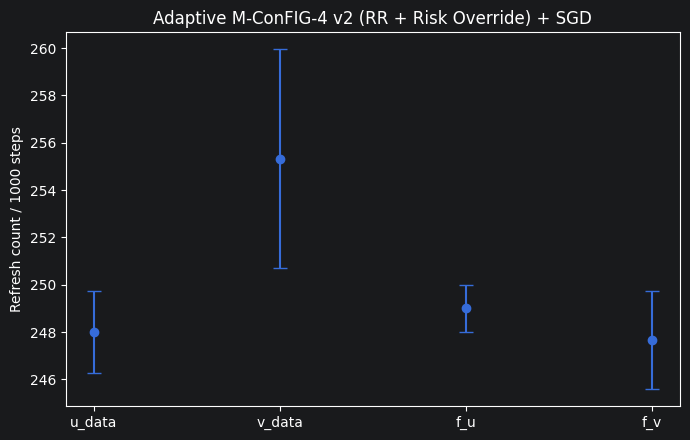

In [25]:

for method in METHODS:
    label = model_name(method)

    rows = [
        r
        for r in refresh_summary_rows
        if r["method"] == label
    ]

    if not rows:
        continue

    tasks = [r["task"] for r in rows]
    counts = [
        float(r["mean_refresh_count"])
        for r in rows
    ]
    stds = [
        0.0
        if not np.isfinite(
            float(r["std_refresh_count"])
        )
        else float(r["std_refresh_count"])
        for r in rows
    ]

    x = np.arange(len(tasks))

    plt.figure(figsize=(7, 4.5))
    plt.errorbar(
        x,
        counts,
        yerr=stds,
        fmt="o",
        capsize=5,
    )
    plt.xticks(x, tasks)
    plt.ylabel("Refresh count / 1000 steps")
    plt.title(label)
    plt.tight_layout()
    plt.savefig(
        AGG_DIR
        / f"{method}_refresh_allocation.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()


# 可视化：v2 每个 seed 的 Physics Convergence


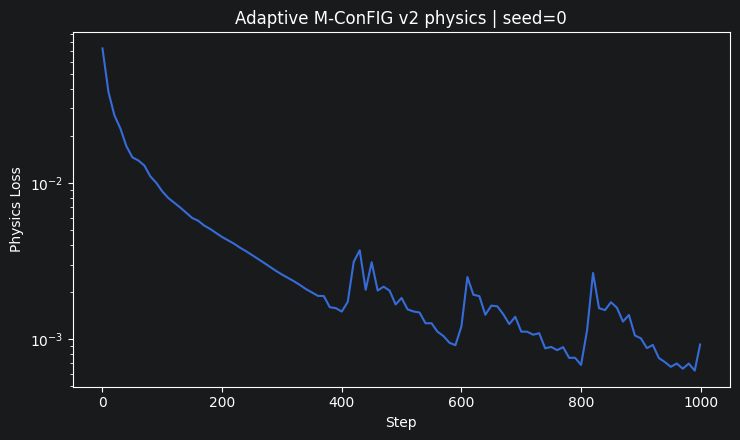

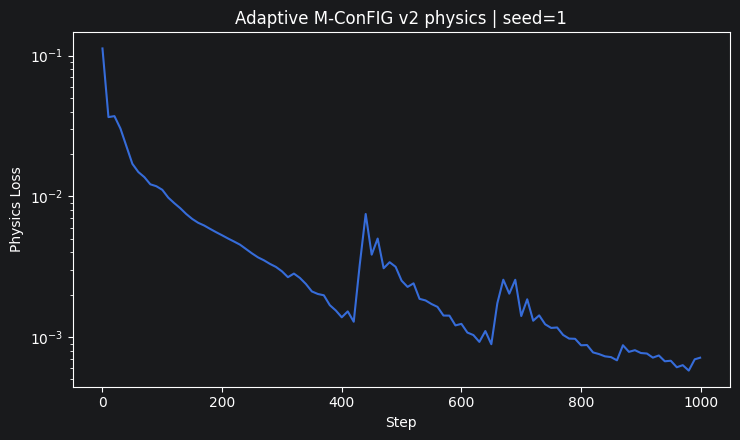

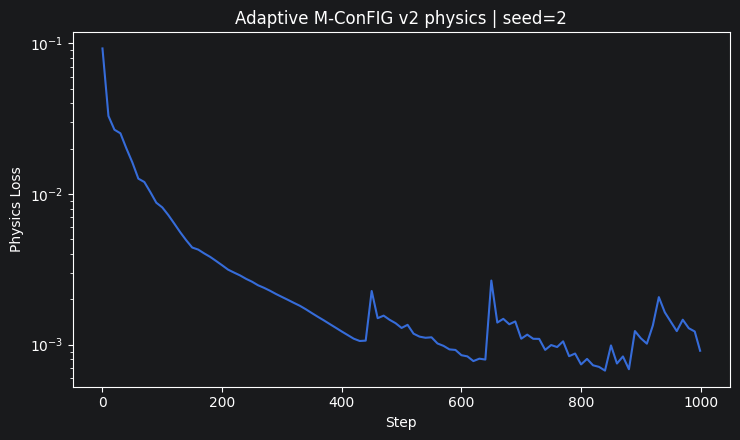

In [26]:
label = model_name(METHOD_KEY)

for seed in RUN_SEEDS:
    rows = [
        r
        for r in all_metric_rows
        if (
            r["method"] == label
            and int(r["seed"]) == seed
        )
    ]

    if not rows:
        continue

    rows = sorted(
        rows,
        key=lambda r: int(r["step"]),
    )

    plt.figure(figsize=(7.5, 4.5))
    plt.semilogy(
        [int(r["step"]) for r in rows],
        [float(r["physics"]) for r in rows],
    )
    plt.xlabel("Step")
    plt.ylabel("Physics Loss")
    plt.title(
        f"Adaptive M-ConFIG v2 physics | seed={seed}"
    )
    plt.tight_layout()
    plt.savefig(
        AGG_DIR
        / f"seed_{seed}_v2_physics.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()


# 可视化：v2 前 250 step 的 task 选择


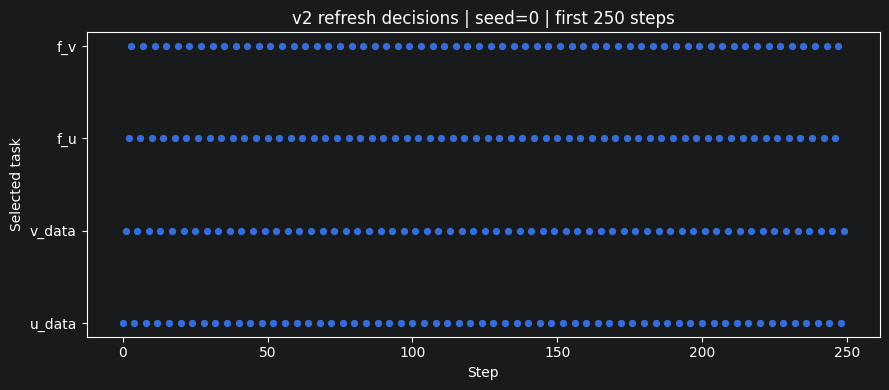

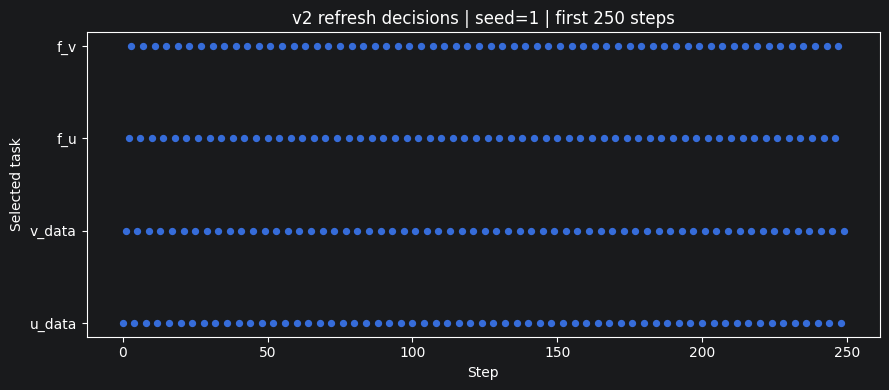

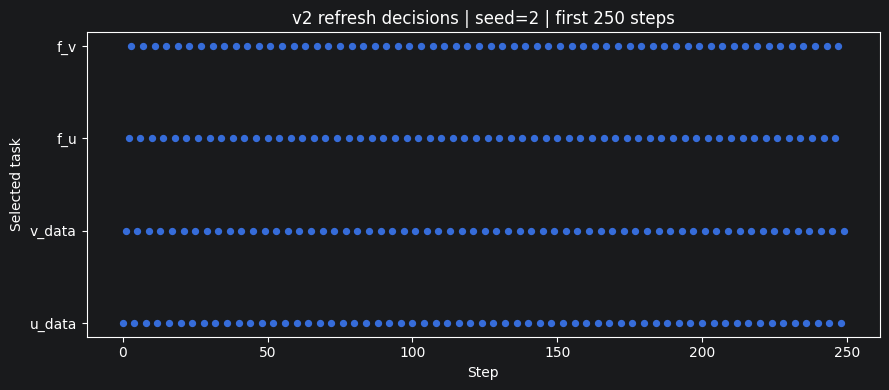

In [27]:
label = model_name(METHOD_KEY)

for seed in RUN_SEEDS:
    rows = [
        r
        for r in all_scheduler_rows
        if (
            r["method"] == label
            and int(r["seed"]) == seed
            and int(r["step"]) < 250
        )
    ]

    if not rows:
        continue

    plt.figure(figsize=(9, 4.0))
    plt.scatter(
        [int(r["step"]) for r in rows],
        [int(r["selected_index"]) for r in rows],
        s=18,
    )
    plt.yticks(
        range(len(LOSS_KEYS)),
        LOSS_KEYS,
    )
    plt.xlabel("Step")
    plt.ylabel("Selected task")
    plt.title(
        f"v2 refresh decisions | seed={seed} | first 250 steps"
    )
    plt.tight_layout()
    plt.savefig(
        AGG_DIR
        / f"seed_{seed}_v2_selection_first250.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()


# 可视化：v2 Risk/Max-Age Preemption 事件


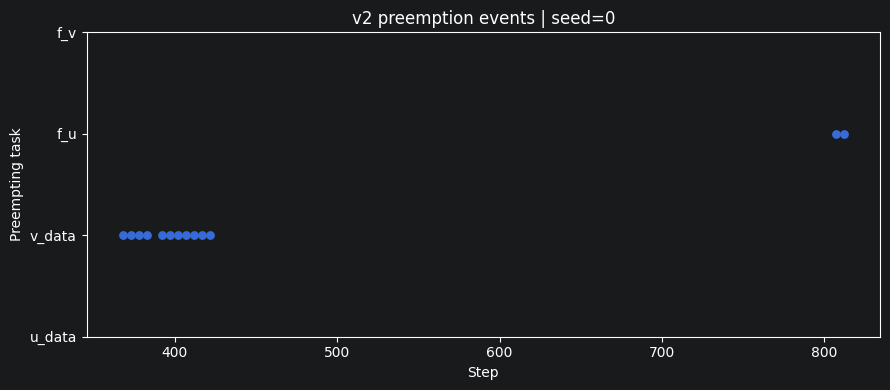

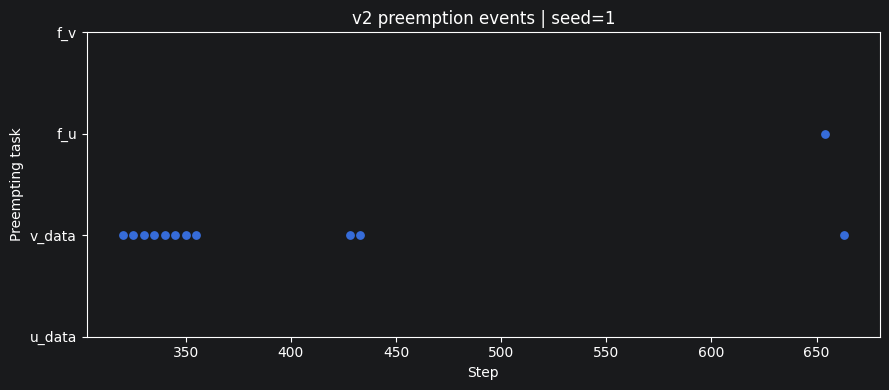

seed=2: no preemption event.


In [28]:
for seed in RUN_SEEDS:
    rows = [
        r
        for r in all_override_rows
        if int(r["seed"]) == seed
    ]

    if not rows:
        print(f"seed={seed}: no preemption event.")
        continue

    plt.figure(figsize=(9, 4.0))
    plt.scatter(
        [int(r["step"]) for r in rows],
        [LOSS_INDEX[r["selected_task"]] for r in rows],
        s=28,
    )
    plt.yticks(
        range(len(LOSS_KEYS)),
        LOSS_KEYS,
    )
    plt.xlabel("Step")
    plt.ylabel("Preempting task")
    plt.title(
        f"v2 preemption events | seed={seed}"
    )
    plt.tight_layout()
    plt.savefig(
        AGG_DIR
        / f"seed_{seed}_v2_preemption_events.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()


# 如何判断 v2 值不值得继续

重点检查：

```text
1. preemption_rate
2. risk_override_count vs max_age_preemption_count
3. refresh allocation
4. update-vs-fresh alignment
5. 1e-3 / 5e-4 physics thresholds
6. u / v / aligned-p field error
7. algorithm wall time + adaptive overhead
8. max_core_peak_vram_mib
```

比较理想的行为是“主要走 RR，只对少数高风险 step 干预”。

例如 10%-20% preemption 可以作为一个直觉上的保守区间，但**不是预先规定的成功阈值**，也不应为了落进这个区间而反向调参。


# 输出文件


In [29]:
print(OUTPUT_ROOT.resolve())

print(
    """
Expected output:

navier_stokes_adaptive_mconfig4_rr_override_v2/
├── seed_0/
│   └── adaptive_mconfig4_rr_override_v2/
│       ├── model.pt
│       ├── scheduler_history.csv
│       ├── metric_history.csv
│       ├── probe_history.csv
│       ├── override_events.csv
│       ├── refresh_counts.csv
│       ├── selection_reason_counts.csv
│       ├── field_metrics.csv
│       ├── threshold_steps.csv
│       ├── predictions.npz
│       └── run_meta.json
├── seed_1/
├── seed_2/
└── aggregate/
    ├── mean_std_summary.csv
    ├── threshold_mean_std.csv
    ├── refresh_allocation_summary.csv
    ├── scheduler_task_diagnostics.csv
    ├── update_fresh_alignment_summary.csv
    ├── staleness_by_task_age.csv
    ├── override_summary_by_seed.csv
    ├── override_mean_std.csv
    ├── override_task_summary.csv
    ├── all_scheduler_history.csv
    ├── all_override_events.csv
    ├── all_probe_history.csv
    └── *.png
"""
)


/home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_adaptive_mconfig4_rr_override_v2

Expected output:

navier_stokes_adaptive_mconfig4_rr_override_v2/
├── seed_0/
│   └── adaptive_mconfig4_rr_override_v2/
│       ├── model.pt
│       ├── scheduler_history.csv
│       ├── metric_history.csv
│       ├── probe_history.csv
│       ├── override_events.csv
│       ├── refresh_counts.csv
│       ├── selection_reason_counts.csv
│       ├── field_metrics.csv
│       ├── threshold_steps.csv
│       ├── predictions.npz
│       └── run_meta.json
├── seed_1/
├── seed_2/
└── aggregate/
    ├── mean_std_summary.csv
    ├── threshold_mean_std.csv
    ├── refresh_allocation_summary.csv
    ├── scheduler_task_diagnostics.csv
    ├── update_fresh_alignment_summary.csv
    ├── staleness_by_task_age.csv
    ├── override_summary_by_seed.csv
    ├── override_mean_std.csv
    ├── override_task_summary.csv
    ├── all_scheduler_history.csv
    ├── all_override_events.csv
    ├── all

# 跑完后优先发给我这些结果

```text
aggregate/mean_std_summary.csv
aggregate/threshold_mean_std.csv
aggregate/refresh_allocation_summary.csv
aggregate/override_summary_by_seed.csv
aggregate/override_mean_std.csv
aggregate/override_task_summary.csv
aggregate/scheduler_task_diagnostics.csv
aggregate/update_fresh_alignment_summary.csv
aggregate/staleness_by_task_age.csv
```

如果 v2 行为异常，再补：

```text
aggregate/all_scheduler_history.csv
aggregate/all_override_events.csv
aggregate/all_probe_history.csv
```
